In [1]:
import nltk

nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All downloads complete!")

[nltk_data] Downloading package movie_reviews to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


All downloads complete!


In [2]:
import pandas as pd
from nltk.corpus import movie_reviews

# Load dataset
reviews = []
for fileid in movie_reviews.fileids():
    label = movie_reviews.categories(fileid)[0]
    text  = movie_reviews.raw(fileid)
    reviews.append((text, label))

df = pd.DataFrame(reviews, columns=['review', 'sentiment'])

print("Dataset Shape:", df.shape)
print(df['sentiment'].value_counts())
df.head()

Dataset Shape: (2000, 2)
sentiment
neg    1000
pos    1000
Name: count, dtype: int64


,review,sentiment
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


/tmp/ipykernel_58/3534681361.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


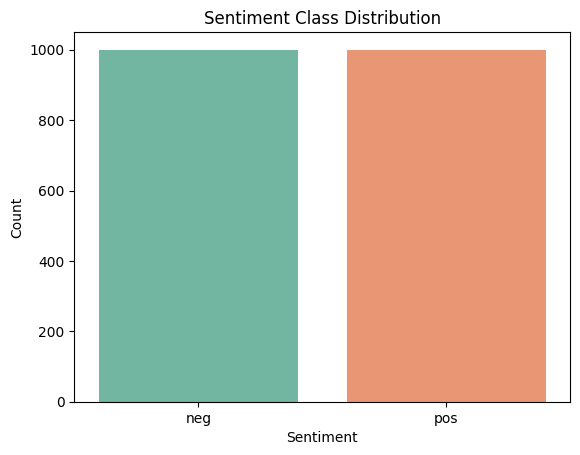

=== 5 POSITIVE REVIEWS ===

Review 1:
films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , b
--------------------------------------------------

Review 2:
every now and then a movie comes along from a suspect studio , with every indication that it will be a stinker , and to everybody's surprise ( perhaps even the studio ) the film becomes a critical dar
--------------------------------------------------

Review 3:
you've got mail works alot better than it deserves to . 
in order to make the film a success , all they had to do was cast two extremely popular and attractive stars , have them share the screen for a
--------------------------------------------------

Review 4:
 " jaws " is a rare film that grabs your attention before it shows you a single image on screen . 
the movie opens with blackness , and only distant , alien-like underwater 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class distribution plot
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# 5 sample positive reviews
print("=== 5 POSITIVE REVIEWS ===\n")
for i, r in enumerate(df[df['sentiment']=='pos']['review'].head(5), 1):
    print(f"Review {i}:\n{r[:200]}\n{'-'*50}\n")

# 5 sample negative reviews
print("=== 5 NEGATIVE REVIEWS ===\n")
for i, r in enumerate(df[df['sentiment']=='neg']['review'].head(5), 1):
    print(f"Review {i}:\n{r[:200]}\n{'-'*50}\n")

In [4]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text, verbose=False):
    # Step 1: Lowercase
    step1 = text.lower()
    if verbose: print(f"1. LOWERCASE:\n{step1[:150]}\n")

    # Step 2: Remove punctuation
    step2 = re.sub(r'[^\w\s]', '', step1)
    if verbose: print(f"2. REMOVE PUNCTUATION:\n{step2[:150]}\n")

    # Step 3: Remove numbers
    step3 = re.sub(r'\d+', '', step2)
    if verbose: print(f"3. REMOVE NUMBERS:\n{step3[:150]}\n")

    # Step 4: Tokenize
    step4 = word_tokenize(step3)
    if verbose: print(f"4. TOKENIZED:\n{step4[:15]}\n")

    # Step 5: Remove stopwords
    step5 = [w for w in step4 if w not in stop_words]
    if verbose: print(f"5. STOPWORDS REMOVED:\n{step5[:15]}\n")

    # Step 6: Lemmatize
    step6 = [lemmatizer.lemmatize(w) for w in step5]
    if verbose: print(f"6. LEMMATIZED:\n{step6[:15]}\n")

    return ' '.join(step6)

# Show step by step on one example
print("=== STEP BY STEP PREPROCESSING ===\n")
sample = df['review'].iloc[0]
print(f"ORIGINAL TEXT:\n{sample[:200]}\n")
print("="*50)
_ = preprocess(sample, verbose=True)

=== STEP BY STEP PREPROCESSING ===

ORIGINAL TEXT:
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
w

1. LOWERCASE:
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continue

2. REMOVE PUNCTUATION:
plot  two teen couples go to a church party  drink and then drive  
they get into an accident  
one of the guys dies  but his girlfriend continues to 

3. REMOVE NUMBERS:
plot  two teen couples go to a church party  drink and then drive  
they get into an accident  
one of the guys dies  but his girlfriend continues to 

4. TOKENIZED:
['plot', 'two', 'teen', 'couples', 'go', 'to', 'a', 'church', 'party', 'drink', 'and', 'then', 'drive', 'they', 'get']

5. STOPWORDS REMOVED:
['plot', 'two', 'teen', 'couples', 'go', 'church', 'party', 'drink', 'drive', '

In [5]:
print("Preprocessing all reviews... (this may take a minute)")

df['cleaned'] = df['review'].apply(preprocess)

print("Done!")
print("\nSample cleaned review:")
print(df['cleaned'].iloc[0][:200])

Preprocessing all reviews... (this may take a minute)
Done!

Sample cleaned review:
plot two teen couple go church party drink drive get accident one guy dy girlfriend continues see life nightmare whats deal watch movie sorta find critique mindfuck movie teen generation touch cool id


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Split dataset
X = df['cleaned']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f"\n=== BAG OF WORDS ===")
print(f"Vocabulary Size  : {len(bow_vectorizer.vocabulary_)}")
print(f"Matrix Shape     : {X_train_bow.shape}")
print(f"Sample Vocab     : {list(bow_vectorizer.vocabulary_.keys())[:10]}")

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f"\n=== TF-IDF ===")
print(f"Vocabulary Size  : {len(tfidf_vectorizer.vocabulary_)}")
print(f"Matrix Shape     : {X_train_tfidf.shape}")
print(f"Sample Vocab     : {list(tfidf_vectorizer.vocabulary_.keys())[:10]}")

Training samples : 1600
Testing samples  : 400

=== BAG OF WORDS ===
Vocabulary Size  : 5000
Matrix Shape     : (1600, 5000)
Sample Vocab     : ['watching', 'loser', 'occurred', 'amy', 'true', 'genius', 'filmmaker', 'casting', 'fast', 'time']

=== TF-IDF ===
Vocabulary Size  : 5000
Matrix Shape     : (1600, 5000)
Sample Vocab     : ['watching', 'loser', 'occurred', 'amy', 'true', 'genius', 'filmmaker', 'casting', 'fast', 'time']


In [7]:
from sklearn.linear_model import LogisticRegression

# Train BoW Model
print("Training BoW Model...")
bow_model = LogisticRegression(max_iter=1000)
bow_model.fit(X_train_bow, y_train)
print("BoW Model Trained! ✅")

# Train TF-IDF Model
print("\nTraining TF-IDF Model...")
tfidf_model = LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train_tfidf, y_train)
print("TF-IDF Model Trained! ✅")

Training BoW Model...
BoW Model Trained! ✅

Training TF-IDF Model...
TF-IDF Model Trained! ✅



=== BoW Model ===
Accuracy: 0.8200
Precision: 0.8177
Recall: 0.8259
F1 Score: 0.8218


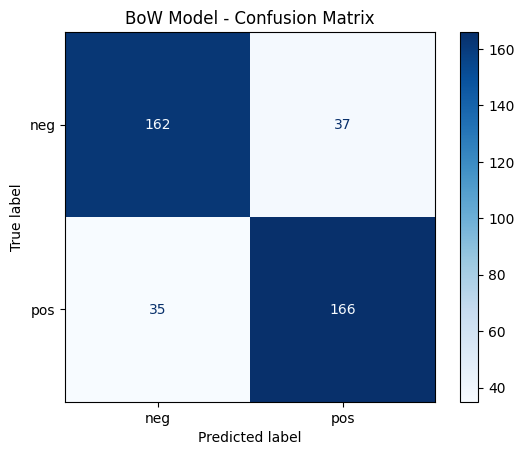


=== TF-IDF Model ===
Accuracy: 0.8275
Precision: 0.8267
Recall: 0.8308
F1 Score: 0.8288


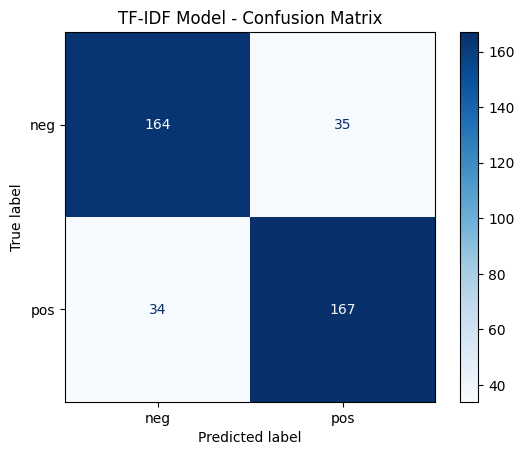


=== COMPARISON TABLE ===
        Accuracy  Precision    Recall  F1 Score
BoW       0.8200   0.817734  0.825871  0.821782
TF-IDF    0.8275   0.826733  0.830846  0.828784


In [8]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    
    metrics = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label='pos'),
        "Recall"   : recall_score(y_test, y_pred, pos_label='pos'),
        "F1 Score" : f1_score(y_test, y_pred, pos_label='pos'),
    }
    
    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['neg', 'pos'])
    disp.plot(cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    
    return metrics

# Evaluate both models
bow_metrics   = evaluate_model(bow_model,   X_test_bow,   y_test, "BoW Model")
tfidf_metrics = evaluate_model(tfidf_model, X_test_tfidf, y_test, "TF-IDF Model")

# Comparison Table
print("\n=== COMPARISON TABLE ===")
comparison = pd.DataFrame([bow_metrics, tfidf_metrics], index=["BoW", "TF-IDF"])
print(comparison.to_string())

Top 10 Positive Words: ['excellent', 'quite', 'family', 'well', 'truman', 'war', 'also', 'life', 'performance', 'great']
Top 10 Negative Words: ['bad', 'plot', 'worst', 'stupid', 'nothing', 'boring', 'supposed', 'attempt', 'minute', 'waste']


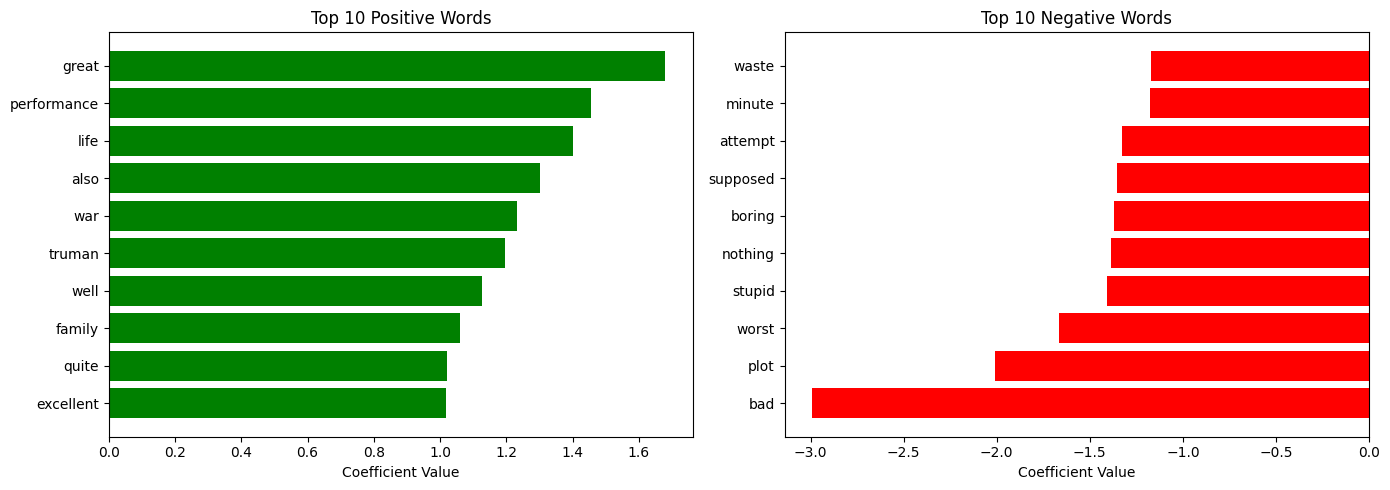

In [9]:
import numpy as np

feature_names = tfidf_vectorizer.get_feature_names_out()
coef = tfidf_model.coef_[0]

# Top 10 positive and negative words
top_pos_idx = np.argsort(coef)[-10:]
top_neg_idx = np.argsort(coef)[:10]

top_pos_words = [feature_names[i] for i in top_pos_idx]
top_neg_words = [feature_names[i] for i in top_neg_idx]

print("Top 10 Positive Words:", top_pos_words)
print("Top 10 Negative Words:", top_neg_words)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_pos_words, coef[top_pos_idx], color='green')
axes[0].set_title("Top 10 Positive Words")
axes[0].set_xlabel("Coefficient Value")

axes[1].barh(top_neg_words, coef[top_neg_idx], color='red')
axes[1].set_title("Top 10 Negative Words")
axes[1].set_xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

In [10]:
custom_reviews = [
    "This movie was absolutely fantastic! Great acting and brilliant story.",
    "Terrible film. Complete waste of time. Boring and very predictable.",
    "The cinematography was beautiful but the plot was very weak and bad.",
    "One of the best movies I have seen in years. Excellent performance!",
    "Awful experience. Bad acting, horrible script, and worst direction ever."
]

print("=== CUSTOM REVIEW PREDICTIONS ===\n")
for i, review in enumerate(custom_reviews, 1):
    cleaned = preprocess(review)
    vec     = tfidf_vectorizer.transform([cleaned])
    pred    = tfidf_model.predict(vec)[0]
    conf    = tfidf_model.predict_proba(vec).max()
    
    print(f"Review {i}  : {review}")
    print(f"Sentiment  : {pred.upper()}")
    print(f"Confidence : {conf:.2%}")
    print("-" * 60)

=== CUSTOM REVIEW PREDICTIONS ===

Review 1  : This movie was absolutely fantastic! Great acting and brilliant story.
Sentiment  : POS
Confidence : 66.32%
------------------------------------------------------------
Review 2  : Terrible film. Complete waste of time. Boring and very predictable.
Sentiment  : NEG
Confidence : 86.41%
------------------------------------------------------------
Review 3  : The cinematography was beautiful but the plot was very weak and bad.
Sentiment  : NEG
Confidence : 77.50%
------------------------------------------------------------
Review 4  : One of the best movies I have seen in years. Excellent performance!
Sentiment  : POS
Confidence : 85.89%
------------------------------------------------------------
Review 5  : Awful experience. Bad acting, horrible script, and worst direction ever.
Sentiment  : NEG
Confidence : 87.64%
------------------------------------------------------------


In [11]:
import joblib

# Save models
joblib.dump(bow_model,        'bow_model.pkl')
joblib.dump(tfidf_model,      'tfidf_model.pkl')
joblib.dump(bow_vectorizer,   'bow_vectorizer.pkl')
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

print("All models saved! ✅")

All models saved! ✅


## Task 9: Comparative Analysis Report

### 1. Which feature extraction technique performed better?
TF-IDF performed better than Bag of Words in all metrics:
- BoW Accuracy: 82.00%
- TF-IDF Accuracy: 82.75%

### 2. Why did TF-IDF perform better?
TF-IDF assigns higher weight to rare but important words and reduces 
the weight of common words that appear in many documents. This helps 
the model focus on more meaningful words for sentiment prediction, 
unlike BoW which treats all words equally based on frequency.

### 3. Advantages and Limitations of Bag of Words
**Advantages:**
- Simple and easy to implement
- Works well for small datasets
- Fast to compute

**Limitations:**
- Ignores word importance (all words treated equally)
- Does not consider word order or context
- Common words can dominate the features

### 4. Advantages and Limitations of TF-IDF
**Advantages:**
- Gives higher weight to important and rare words
- Reduces impact of very common words
- Better representation of text meaning

**Limitations:**
- Still ignores word order and context
- Cannot capture semantic meaning of words
- Slightly more complex than BoW

### 5. Recommendation for Real-World Application
TF-IDF is recommended for real-world sentiment analysis because it 
produces better accuracy by focusing on meaningful words. However, 
for even better results, deep learning models like BERT should be 
considered as they understand context and word meaning much better.